# Comparison of DRT Software

# Testing DRTs

In [2]:
# %load_ext autoreload
# %autoreload 2
# if think is slowing down, disable autoreload by restarting kernel without it.

import numpy as np
import pandas as pd


from redoxed.data_loading.data_loaders import LoaderFactory, BiologicLoader, CSVLoader
from redoxed.plots.eis_plot import NyquistPlot
from redoxed.plots.drt_plot import DRTPlot
from redoxed.impedance import EISData, DRTData

import pyDRTtools

from pyimpspec import (
  DataSet,
  DRTResult,              # An abstract class for DRT results
  calculate_drt,          # Wrapper function for all methods
  generate_mock_data,
)
from pyimpspec.analysis.drt import (
  BHTResult,              # Result of the BHT method
  LMResult,               # Result of the Loewner method
  MRQFitResult,           # Result of the m(RQ)fit method
  TRNNLSResult,           # Result of the TR-NNLS method
  TRRBFResult,            # Result of the TR-RBF method
  calculate_drt_bht,      # BHT method
  calculate_drt_lm,       # Loewner method
  calculate_drt_mrq_fit,  # m(RQ)fit method
  calculate_drt_tr_nnls,  # TR-NNLS method
  calculate_drt_tr_rbf,   # TR-RBF method
)



from nanodrt.dataobjects.dataobject import EISDataObject
from nanodrt.calculators import ImpedanceCalculator
from nanodrt.radialbasisfunctions import GaussianRBF
from nanodrt.optimizers import ImpedanceOptimizer
import jax.numpy as jnp

%matplotlib inline

Initializing pyDRTtools from c:\users\es758\documents\github\pydrttools
['c:\\Users\\es758\\anaconda3\\envs\\RFB_es758\\python313.zip', 'c:\\Users\\es758\\anaconda3\\envs\\RFB_es758\\DLLs', 'c:\\Users\\es758\\anaconda3\\envs\\RFB_es758\\Lib', 'c:\\Users\\es758\\anaconda3\\envs\\RFB_es758', '', 'c:\\Users\\es758\\anaconda3\\envs\\RFB_es758\\Lib\\site-packages', 'C:\\Users\\es758\\Documents\\GitHub\\redoxED\\src', 'c:\\users\\es758\\documents\\github\\pydrttools', 'c:\\users\\es758\\documents\\github\\nanodrt', 'C:\\Users\\es758\\Documents\\GitHub\\phd_tools', 'c:\\Users\\es758\\anaconda3\\envs\\RFB_es758\\Lib\\site-packages\\win32', 'c:\\Users\\es758\\anaconda3\\envs\\RFB_es758\\Lib\\site-packages\\win32\\lib', 'c:\\Users\\es758\\anaconda3\\envs\\RFB_es758\\Lib\\site-packages\\Pythonwin', 'c:\\Users\\es758\\anaconda3\\envs\\RFB_es758\\Lib\\site-packages\\yadg']
Imported basics
Imported BHT
Imported cli
Imported GUI
Imported HMC
Imported layout
Imported nearest_PD
Imported parameter_sele

## Simple Data

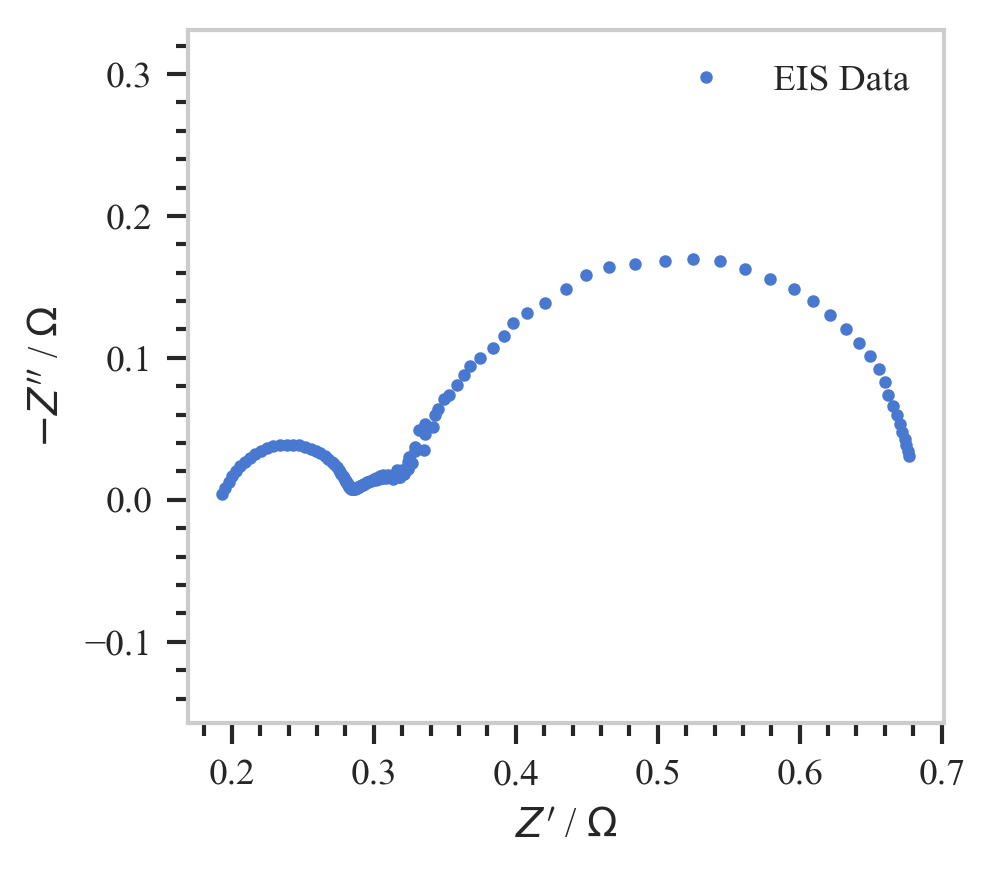

In [3]:
fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Documents\Lent 2025\time_data\30787_EIS_data.csv"
data = CSVLoader().load_data(fpath=fpath)   
data.df
column_mapping = {
            "Z_re": "Z_re",
            "-Z_im": None,
            "f": "f",
            "Z": None,
            "Z_im": 'Z_im',
        }
EISData_object = data.to_EISData(column_mapping=column_mapping)

EISData_object.trim_inductive()


data_plot = NyquistPlot(figsize=(3.25, 3), dpi=300) 
data_plot.add_plot(EISData_object, label = "EIS Data", linestyle = "", marker = "o", markersize = 2)

### Plot formatting
## Ensure ratio equal
# data_plot.ax.set_aspect("equal", adjustable="datalim")  # if enable, overall fig size will be strictly enforced, but x and y limits will be overwritten. So will padding of labels I think.
# data_plot.ax.set_aspect('equal',adjustable='box') # if enable this, fig size will get overwritten, at least in y. but can set x and y lim
## Cropping
# data_plot.ax.set_ylim([0.01, None]) # can always edit afterwards like most settings with something like
## Embellishments
data_plot.add_major_ticks(major_tick_spacing = 0.1)
data_plot.add_minor_ticks(major_tick_spacing = 5)
# data_plot.ax.grid(True)
# data_plot.ax.legend(bbox_to_anchor=(0., 0.9), loc="upper left") # manual legend settings
data_plot.ax.legend()

display(data_plot.fig)

### pyDRTtools

In [31]:
# Load measurement data into EIS_object
pyDRTtools_EIS_object = pyDRTtools.runs.EIS_object(
    EISData_object.f, EISData_object.Z_re, EISData_object.Z_im, ed_adjust = False
)
# this includes tau definition of
# # self.tau = 1/freq # we assume that the collocation points equal to 1/freq as default
# # self.tau_fine  = np.logspace(log10(self.tau.min())-0.5,log10(self.tau.max())+0.5,10*freq.shape[0])


induct_used = 1 # 1 means do keep inductive and fit inductance.
der_used = '1st order'
cv_type = 'custom' # fix lambda
lambda_0 = 1e-9 # initial guess
reg_param = lambda_0
shape_control = "FWHM Coefficient" # otherwise coeff is treated as their definition of shape factor mu
coeff = 0.5 # FWHM twice log spacing means coef 0.5. Is done so there is good overlap.
rbf_type = "Gaussian" # Gaussian is the default, but can also use 'Cauchy', 'Lorentzian', 'Exponential', 'Polynomial', 'Ridge' or 'Laplacian'
data_used = "Combined Re-Im Data"
# ridge regression DRT
fitted_entry = pyDRTtools.runs.simple_run(
    entry=pyDRTtools_EIS_object,
    rbf_type=rbf_type,
    data_used=data_used,
    induct_used=induct_used,
    der_used=der_used,
    cv_type=cv_type,
    reg_param=reg_param,
    shape_control=shape_control,
    coeff=coeff,
)
### If want to mute the console, can use something like this with simple_run nested in
# # Redirecting stdout to capture the output
# with io.StringIO() as output, contextlib.redirect_stdout(output):

gamma_pyDRTtools = fitted_entry.gamma # is tau_fine from DRTtools, not tau used for fitting x. padded values.
tau_pyDRTtools = fitted_entry.out_tau_vec
DRT_object_pyDRTtools = DRTData(tau = tau_pyDRTtools, gamma = gamma_pyDRTtools, label = "pyDRTtools")
R_pyDRTtools = fitted_entry.R
L_pyDRTtools = fitted_entry.L
lambda_value_pyDRTtools = fitted_entry.lambda_value 
Z_pyDRTtools = fitted_entry.mu_Z_re + 1j*fitted_entry.mu_Z_im
EISData_fitted_pyDRTtools = EISData(f = fitted_entry.freq, Z = Z_pyDRTtools, label = "pyDRTtools")

print(f"R = {R_pyDRTtools}, L = {L_pyDRTtools}, lambda = {lambda_value_pyDRTtools}")


The value of the regularization parameter is 1e-09
     pcost       dcost       gap    pres   dres
 0: -2.0337e+01 -2.2723e+01  2e+02  1e+01  6e-05
 1: -1.8790e+01 -2.4157e+01  8e+00  2e-01  9e-07
 2: -1.9929e+01 -2.1263e+01  1e+00  2e-02  8e-08
 3: -2.0231e+01 -2.0566e+01  3e-01  3e-03  1e-08
 4: -2.0318e+01 -2.0444e+01  1e-01  3e-05  1e-10
 5: -2.0343e+01 -2.0364e+01  2e-02  4e-07  2e-12
 6: -2.0349e+01 -2.0352e+01  3e-03  4e-09  2e-14
 7: -2.0350e+01 -2.0351e+01  2e-03  1e-16  1e-16
 8: -2.0350e+01 -2.0350e+01  3e-04  3e-16  3e-16
 9: -2.0350e+01 -2.0350e+01  1e-04  3e-16  2e-16
10: -2.0350e+01 -2.0350e+01  2e-05  2e-16  4e-16
11: -2.0350e+01 -2.0350e+01  3e-06  4e-16  4e-17
12: -2.0350e+01 -2.0350e+01  2e-06  2e-16  1e-16
13: -2.0350e+01 -2.0350e+01  4e-07  1e-16  2e-16
14: -2.0350e+01 -2.0350e+01  1e-07  2e-17  2e-16
15: -2.0350e+01 -2.0350e+01  2e-08  1e-16  9e-17
16: -2.0350e+01 -2.0350e+01  4e-10  3e-16  1e-16
17: -2.0350e+01 -2.0350e+01  5e-12  2e-16  4e-16
18: -2.0350e+01 -2.

### pyimpspec

In [5]:
data: DataSet = DataSet(frequencies = EISData_object.f, impedances = EISData_object.Z, mask = None, path = "", label = "", uuid = "")
lambda_value = 1e-3
drt: TRNNLSResult = calculate_drt_tr_rbf(data, mode= 'complex', method="tr-rbf", lambda_value=lambda_value, cross_validation='', inductance = True, derivative_order = 1, rbf_shape = 'fwhm')

# def calculate_drt_tr_rbf(
#     data: DataSet,
#     mode: str = "complex",
#     lambda_value: float = -1.0,
#     cross_validation: str = "mgcv",
#     rbf_type: str = "gaussian",
#     derivative_order: int = 1,
#     rbf_shape: str = "fwhm",
#     shape_coeff: float = 0.5,
#     inductance: bool = False,
#     credible_intervals: bool = False,
#     num_samples: int = 2000,
#     timeout: int = 60,
#     num_procs: int = -1,
#     **kwargs,

gamma_pyimpspec = drt.gammas
tau_pyimpspec = drt.time_constants
DRT_object_pyimpspec = DRTData(tau = tau_pyimpspec, gamma = gamma_pyimpspec, label = "pyimpspec")
R_pyimpspec = np.nan
L_pyimpspec = np.nan
lambda_value_pyimpspec = drt.lambda_value
EISData_fitted_pyimpspec = EISData(f = drt.frequencies, Z = drt.impedances, label = "pyimpspec")

## nanodrt

In [71]:
nanodrt_eis_object = EISDataObject(
            Z_re=jnp.array(EISData_object.Z_re), Z_im=jnp.array(EISData_object.Z_im), f=jnp.array(EISData_object.f)
        )

# calculate appropriate mu is a placeholder
# find spacing in log space
ln_f = np.log(nanodrt_eis_object.f)
# Compute the differences between consecutive elements
ln_spacing = np.diff(ln_f)
spacing = np.mean(np.abs(ln_spacing))
# assume FWHM should be 1/coeff spacing
coeff = 0.5  # FWHM twice log spacing is coef 0.5. IS done so there is good overlap.
FWHM = spacing / coeff
# calculate mu for gaussian RBF
mu = 2 * (np.log(2) ** 0.5) / FWHM
mu = 1.4 # temp


# Tau values
tau_values = 1 / (nanodrt_eis_object.f * 2 * np.pi) # tau values for the DRT
# tau_values = 1 / (nanodrt_eis_object.f) # tau values for the DRT (consistentcy with pyDRTtools)

# Create instance of RBF
config = {"mu": mu}
rbf = GaussianRBF(config)
freq_values = nanodrt_eis_object.f  # frequency values from the EIS data
lambda_value = 1e-3

# Create ImpedanceCalculator instance
calculator = ImpedanceCalculator(
    rbf, tau_values, freq_values, dy=0.001, y_max=10, y_min=-10
)
# initial guess assuming all ones
x_values = jnp.ones(len(tau_values) + 2)

# run
optimizer = ImpedanceOptimizer(calculator, nanodrt_eis_object)
# optimizer.add_regularisation(lambda_value=lambda_value)
results = optimizer.run(
    x_values, method="scipy", config={"method": "BFGS", "maxiter": 1e6}
)  # lowered from 10000
nanodrt_Z = calculator.simulate(
    results.params[:-2], results.params[-2], results.params[-1]
)

tau_nanodrt = tau_values
gamma_nanodrt = calculator.simulate_gamma(results.params[:-2])
DRT_object_nanodrt = DRTData(tau = tau_nanodrt, gamma = gamma_nanodrt, label = "nanodrt")
R_nanodrt = results.params[-2]
L_nanodrt = results.params[-1]
lambda_value_nanodrt = lambda_value
EISData_fitted_nanodrt = EISData(f = freq_values, Z = nanodrt_Z, label = "nanodrt")

## Plots

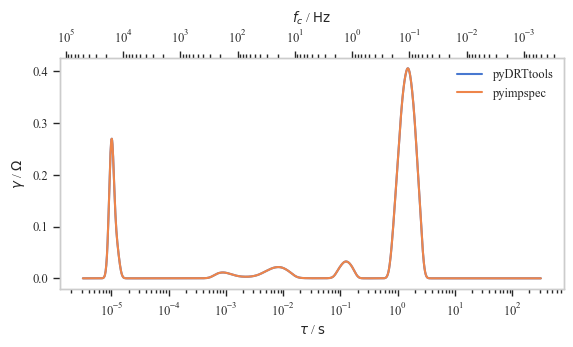

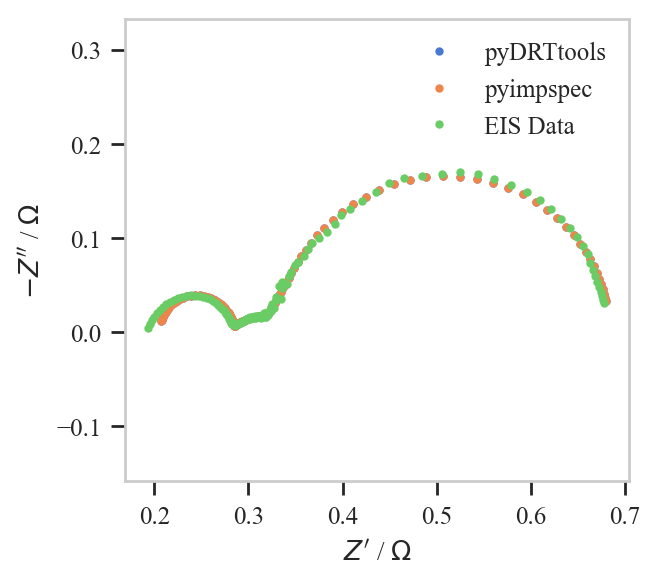

In [8]:
data_plot = DRTPlot(figsize=(6.5, 3), dpi=100) 
data_plot.add_plot(DRT_object_pyDRTtools, linestyle = "-", marker = "")
data_plot.add_plot(DRT_object_pyimpspec, linestyle = "-", marker = "")
# data_plot.add_plot(DRT_object_nanodrt, linestyle = "-", marker = "")

### Plot formatting
## Cropping
# data_plot.ax.set_ylim([0.01, None]) 
## Embellishments
data_plot.add_major_ticks(major_tick_spacing = 0.1)
# data_plot.add_minor_ticks(major_tick_spacing = 5)
# data_plot.ax.grid(True)
# data_plot.ax.legend(bbox_to_anchor=(0., 0.9), loc="upper left") # manual legend settings
data_plot.ax.legend()

data_plot.add_fc_axis()

display(data_plot.fig)

data_plot = NyquistPlot(figsize=(3.25, 3), dpi=200) 
data_plot.add_plot(EISData_fitted_pyDRTtools, linestyle = "", marker = "o", markersize = 2)
data_plot.add_plot(EISData_fitted_pyimpspec, linestyle = "", marker = "o", markersize = 2)
# data_plot.add_plot(EISData_fitted_nanodrt, linestyle = "", marker = "o", markersize = 2)
data_plot.add_plot(EISData_object, linestyle = "", marker = "o", markersize = 2, label = "EIS Data")

### Plot formatting
## Ensure ratio equal
# data_plot.ax.set_aspect("equal", adjustable="datalim")  # if enable, overall fig size will be strictly enforced, but x and y limits will be overwritten.
# data_plot.ax.set_aspect('equal',adjustable='box') # if enable this, fig size will get overwritten, at least in y, but can set x and y lim.
## Cropping
# data_plot.ax.set_ylim([0.01, None]) # Use invisible points if not achieving desired ax limits
## Embellishments
#data_plot.add_major_ticks(major_tick_spacing = 0.1)
#data_plot.add_minor_ticks(major_tick_spacing = 5)
# data_plot.ax.grid(True)
data_plot.ax.legend()
#data_plot.ax.legend(ncols = 2, bbox_to_anchor=(0., 1), loc="upper left", fontsize = 8) # manual legend settings


display(data_plot.fig)

## Ciucci fGP

In [45]:
import redoxed.impedance.ciucci_finite_GP_DRT as finite_GP_DRT
from scipy.optimize import minimize

# gamma_pyDRTtools = fitted_entry.gamma # is tau_fine from DRTtools, not tau used for fitting x. padded values.
# tau_pyDRTtools = fitted_entry.out_tau_vec
# DRT_object_pyDRTtools = DRTData(tau = tau_pyDRTtools, gamma = gamma_pyDRTtools, label = "pyDRTtools")
# R_pyDRTtools = fitted_entry.R
# L_pyDRTtools = fitted_entry.L
# lambda_value_pyDRTtools = fitted_entry.lambda_value 
# Z_pyDRTtools = fitted_entry.mu_Z_re + 1j*fitted_entry.mu_Z_im
# EISData_fitted_pyDRTtools = EISData(f = fitted_entry.freq, Z = Z_pyDRTtools, label = "pyDRTtools")



# define the range of log timescales with tau=1/f as in the previous papers
freq_vec = EISData_object.f # frequency vector in Hz
N_freqs = len(freq_vec)
# make tau defined by frequencies
tau_vec = 1/(freq_vec*2*np.pi) # tau values for the DRT
N_taus = N_freqs
log_tau_vec = np.log(tau_vec)

# Form Z_re_im matrix
Z_exp_re_im = np.zeros(2*N_freqs)
Z_exp_re_im[:N_freqs] = EISData_object.Z_re
Z_exp_re_im[N_freqs:] = EISData_object.Z_im

# compute A_re and A_im
A_re = finite_GP_DRT.compute_A_re(freq_vec, tau_vec)
A_im = finite_GP_DRT.compute_A_im(freq_vec, tau_vec)
# matrix A
A = np.zeros((2*N_freqs, N_taus+2))
# real part
A[:N_freqs, 1] = 1.0
A[:N_freqs, 2:] = A_re
# imaginary part
# A[N_freqs:, 0] = 2*np.pi*freq_vec*1E-4 # above note normalization by 1E-4 
# # not sure what is going on here. in equation lookls like 2pif.
# 1e-4 is minimum tau they used
A[N_freqs:, 0] = 2*np.pi*freq_vec # am trying this to see if it works better, otherwise surely suppressing L or something
A[N_freqs:, 2:] = A_im

# optimise hyperparameter selection for unconstrained GP-DRT by minimising NMLL
# initial parameters to maximize the marginal log-likelihood
sigma_n = 0.1
sigma_L = 0.1
sigma_R = 3.0
sigma_f = 0.1
ell =  1.2
theta_0 = np.array([sigma_n, sigma_L, sigma_R, sigma_f, ell])
#print(theta_0)
# NMLL optimisation
seq_theta = np.copy(theta_0)
def print_results(theta): # have mostly commented out because I have a problem with the global seq_theta in the way I am using it
    iteration=0
#     global seq_theta
#     seq_theta = np.vstack((seq_theta, theta))
#     print('{0:.7f}  {1:.7f}  {2:.7f}  {3:.7f}  {4:.7f}'.format(theta[0], theta[1], theta[2], theta[3], theta[4]))

# print('sigma_n,   sigma_L,   sigma_R,   sigma_f,   ell')
# minimize the NMLL L(\theta) w.r.t sigma_n, sigma_R, sigma_f, and ell
res = minimize(finite_GP_DRT.NMLL_L_fct, theta_0, args=(A, Z_exp_re_im, N_freqs, log_tau_vec), method='L-BFGS-B', \
                callback=print_results, options={'disp': True})

# res = minimize(finite_GP_DRT.NMLL_L_fct, theta_0, args=(A, Z_exp_re_im, N_freqs, log_tau_vec), method='Powell', \
#                 callback=print_results, options={'disp': True})

# collect the optimized parameters
sigma_n, sigma_L, sigma_R, sigma_f, ell = res.x

print("Hyperparemeter selection")
print(res.x)

# compute the matrix K
K = finite_GP_DRT.compute_K(log_tau_vec, sigma_f, ell)
# compute the matrix Gamma
Gamma = np.zeros((N_taus+2, N_taus+2))
Gamma[0,0] = sigma_L**2
Gamma[1,1] = sigma_R**2
Gamma[2:, 2:] = K
# put together the matrix Gamma
Psi = A@(Gamma@A.T)+(sigma_n**2)*np.eye(2*N_freqs)
Psi = 0.5*(Psi + Psi.T) # symmetrize
Xi = Gamma@A.T

# Cholesky factorization L of Psi -L is a lower-triangular matrix-
L = np.linalg.cholesky(Psi)

# solve for alpha
alpha = np.linalg.solve(L, Z_exp_re_im)
alpha = np.linalg.solve(L.T, alpha)

# obtain mu_x
mu_x_given_Z = np.dot(Xi, alpha)

# covariance matrix
inv_L = np.linalg.inv(L)
inv_Psi = np.dot(inv_L.T, inv_L)

# estimate the covariance matrix of gamma for eq (21b)
Sigma_x_given_Z = Gamma - Xi@(inv_Psi@Xi.T)

# useful definition for plots 
# unc means unconstrained, has been conditioned by now
L_0_unc = mu_x_given_Z[0] 
R_inf_unc = mu_x_given_Z[1] 
cov_R_inf_unc = Sigma_x_given_Z[0, 0]
gamma_GP_unc = mu_x_given_Z[2:]
Sigma_GP_unc = Sigma_x_given_Z[2:, 2:]

print("Conditioning done")

Hyperparemeter selection
[-2.52206094e-03  6.50183620e-02  2.99999047e+00  8.93826076e-02
  1.19937948e+00]
Conditioning done


In [46]:
DRT_object_fGP = DRTData(tau = tau_vec, gamma = gamma_GP_unc, label = "fGP")
print(L_0_unc, R_inf_unc, sigma_n, sigma_L, sigma_R, sigma_f, ell)

3.330696889125573e-08 0.18482963607357306 -0.0025220609379753046 0.06501836196909595 2.9999904688104415 0.08938260762206876 1.1993794767206964


<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
C:\Users\es758\AppData\Local\Temp\ipykernel_9440\46764339.py:3: SyntaxWarning: invalid escape sequence '\s'
  data_plot.ax.fill_between(tau_vec, gamma_GP_unc-3*np.diag(Sigma_GP_unc), gamma_GP_unc+3*np.diag(Sigma_GP_unc), color='0.25', alpha=0.25, label = "3$\sigma$ region")


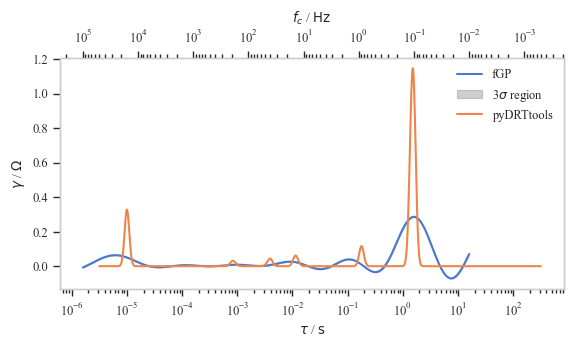

[1.58289089e-03 9.49787996e-04 5.19322633e-04 2.58759842e-04
 1.28386415e-04 8.66540086e-05 9.54220545e-05 1.23817244e-04
 1.50521777e-04 1.64133415e-04 1.61691631e-04 1.46422577e-04
 1.24498940e-04 1.02636529e-04 8.58640317e-05 7.65745654e-05
 7.44425070e-05 7.72935186e-05 8.20613946e-05 8.59876090e-05
 8.73335462e-05 8.56427311e-05 8.16131179e-05 7.66119629e-05
 7.20053592e-05 6.88859278e-05 6.76402281e-05 6.79764899e-05
 6.92219460e-05 7.05661799e-05 7.13305128e-05 7.12073551e-05
 7.02597391e-05 6.88203658e-05 6.73318439e-05 6.61741656e-05
 6.55731528e-05 6.55193803e-05 6.58374972e-05 6.62696363e-05
 6.65771852e-05 6.66192994e-05 6.63730078e-05 6.59272190e-05
 6.54244954e-05 6.50045818e-05 6.47578515e-05 6.47051216e-05
 6.47971145e-05 6.49505806e-05 6.50770218e-05 6.51191192e-05
 6.50575524e-05 6.49172659e-05 6.47434349e-05 6.45884338e-05
 6.44902479e-05 6.44606144e-05 6.44866214e-05 6.45390042e-05
 6.45853501e-05 6.46018843e-05 6.45797808e-05 6.45275947e-05
 6.44630908e-05 6.440934

In [42]:
data_plot = DRTPlot(figsize=(6.5, 3), dpi=100) 
data_plot.add_plot(DRT_object_fGP, linestyle = "-", marker = "")
data_plot.ax.fill_between(tau_vec, gamma_GP_unc-3*np.diag(Sigma_GP_unc), gamma_GP_unc+3*np.diag(Sigma_GP_unc), color='0.25', alpha=0.25, label = "3$\sigma$ region")
### Plot formatting
## Cropping
# data_plot.ax.set_ylim([0.01, None]) 
## Embellishments
# data_plot.add_major_ticks(major_tick_spacing = 0.1)
# data_plot.add_minor_ticks(major_tick_spacing = 5)
# data_plot.ax.grid(True)
# data_plot.ax.legend(bbox_to_anchor=(0., 0.9), loc="upper left") # manual legend settings


data_plot.add_plot(DRT_object_pyDRTtools, linestyle = "-", marker = "")

data_plot.add_fc_axis()

data_plot.ax.legend()

display(data_plot.fig)

# plt.semilogx(tau_vec, gamma_GP_unc, linewidth=2, color='black', label='fGP-DRT-unc')
# plt.fill_between(tau_vec, gamma_GP_unc-3*np.diag(Sigma_GP_unc), gamma_GP_unc+3*np.diag(Sigma_GP_unc), 
#                  color='0.25', alpha=0.25)

print((3*np.diag(Sigma_GP_unc)))

In [38]:
# sample DRT under positivity constraint
# inputs to the Hamilton Monte-Carlo sampler
# F*X+g >0
F = np.eye(N_taus+2)
g = np.zeros(N_taus+2)
# covariance & mean
M = Sigma_x_given_Z + 1E-8*np.eye(N_taus+2) # not sure why they do this rather than just using Sigma_x_given_Z. # might matter if sigma_L or sigma_R is small
print(M)
mu_r = mu_x_given_Z
# initial val
initial_x_given_Z = np.abs(mu_x_given_Z)
samples_raw = finite_GP_DRT.generate_tmg(F, g, M, mu_r, initial_x_given_Z, cov=True, L=10000)

print("Sample non negative done")


# postprocessing
samples = samples_raw[:,1000:] # remove burn in
samples_gamma = samples[2:,:] # slice out only samples of gamma



[[-7.34501686e-04  4.80791982e-07  1.51110324e-09 ... -2.89747881e-13
  -1.45598925e-12 -1.78096361e-13]
 [ 2.84176499e-08  1.16307754e-05 -6.39865115e-05 ... -1.00209245e-08
  -2.53840977e-08 -4.19947163e-08]
 [ 1.30383173e-09 -6.39864934e-05  5.27640297e-04 ...  2.30839139e-07
   3.73016115e-07  5.15284008e-07]
 ...
 [-3.65566265e-13 -1.00008532e-08  2.30839157e-07 ...  7.18012252e-05
   1.02490326e-04  1.34119561e-04]
 [-3.19114809e-13 -2.53795386e-08  3.73016112e-07 ...  1.02490326e-04
   1.55464821e-04  2.12248903e-04]
 [-2.72341725e-13 -4.19928167e-08  5.15284002e-07 ...  1.34119561e-04
   2.12248903e-04  2.98021582e-04]]


TypeError: 'numpy.float64' object cannot be interpreted as an integer

In [ ]:
"""
Somewhere here is where can probably extract R and L, problem is only want them from the median?
"""
# samples_RL = samples[:2,:]
# RL_median = np.nanmedian(samples_RL, axis=1)
series_R = 0
series_L = 0

samples_Z_re_im = A@samples # samples of Z_re_im

gamma_avg = np.average(samples_gamma,axis=1)
gamma_std = np.std(samples_gamma,axis=1)
gamma_median = np.nanmedian(samples_gamma,axis=1)
gamma_percentile_0dot1 = np.percentile(samples_gamma, 1, axis=1)
gamma_percentile_0dot5 = np.percentile(samples_gamma, 50, axis=1)
gamma_percentile_0dot9 = np.percentile(samples_gamma, 99, axis=1)


Z_re_im_avg = np.average(samples_Z_re_im,axis=1)
Z_re_im_std = np.std(samples_Z_re_im,axis=1)
Z_re_im_median = np.nanmedian(samples_Z_re_im,axis=1)
Z_re_im_percentile_0dot1 = np.percentile(samples_Z_re_im, 1, axis=1)
Z_re_im_percentile_0dot5 = np.percentile(samples_Z_re_im, 50, axis=1)
Z_re_im_percentile_0dot9 = np.percentile(samples_Z_re_im, 99, axis=1)

Z_re_median = Z_re_im_median[:N_freqs]
Z_im_median = Z_re_im_median[N_freqs:]

Z_re_percentile_0dot1 = Z_re_im_percentile_0dot1[:N_freqs]
Z_re_percentile_0dot9 = Z_re_im_percentile_0dot9[:N_freqs]
Z_im_percentile_0dot1 = Z_re_im_percentile_0dot1[N_freqs:]
Z_im_percentile_0dot9 = Z_re_im_percentile_0dot9[N_freqs:]

Z_DRT = Z_re_median + 1j*Z_im_median

# self.fGP_DRT_results = [tau_vec, gamma_median, gamma_percentile_0dot1, gamma_percentile_0dot9, self.frequencies, Z_DRT, series_R, series_L]